In [922]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier as dtc
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    r2_score,
    explained_variance_score,
)


from sklearn.feature_selection import mutual_info_classif

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## Task 1: Data Preparation and Goal Statement

### 1.1 Load the Data

For datasets that need merging

In [923]:
# File locations (edit for reuse)
file_path_1 = "example-data/student-performance/student/student-mat.csv"
file_path_2 = "example-data/student-performance/student/student-por.csv"

# MERGE THE DATASETS    
# # Load raw data
# df_1 = pd.read_csv(file_path_1, delimiter=";")
# df_2 = pd.read_csv(file_path_2, delimiter=";")

# # Merge
# merge_cols = [
#     "school", "sex", "age", "address", "famsize", "Pstatus",
#     "Medu", "Fedu", "Mjob", "Fjob", "reason", "nursery", "internet"
# ]
# df_raw = pd.merge(df_1, df_2, on=merge_cols)
# print(df_raw.shape[0])  # Should print 382 students
# df_raw.head()


# CONCAT THE DATASETS
df_1 = pd.read_csv(file_path_1, delimiter=";")
df_2 = pd.read_csv(file_path_2, delimiter=";")

# Append (concatenate) the two datasets
df_raw = pd.concat([df_1, df_2], ignore_index=True)
print(df_raw.shape)
df_raw.head()


(1044, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


For only 1 data set

In [924]:
# # File locations (edit for reuse)
# file_path = "example-data/student-performance/student/student-mat.csv"

# # Load raw data
# df_raw = pd.read_csv(file_path, delimiter=";")
# print(f"Raw shape: {df_raw.shape}")
# df_raw.head()

### 1.2 Standardize Column Names

In [925]:
# Standard column names
df_raw = df_raw.copy()
df_raw.columns = (
    df_raw.columns
    .str.strip()                # Remove leading/trailing spaces
    .str.lower()                # Lowercase all letters
    .str.replace(' ', '_')      # Replace spaces with underscores
)
# rename_map = {
#     # Add your column renaming here, e.g. "old_name": "new_name",
# }
# df_raw = df_raw.rename(columns=rename_map)

### 1.3 Data Inspection

In [926]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   pstatus     1044 non-null   object
 6   medu        1044 non-null   int64 
 7   fedu        1044 non-null   int64 
 8   mjob        1044 non-null   object
 9   fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [927]:
df_raw.describe()

,age,medu,fedu,traveltime,studytime,failures,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [928]:
# Display unique values for all non-numerical columns
non_num_cols = df_raw.select_dtypes(exclude=[np.number]).columns
unique_vals = {col: df_raw[col].unique() for col in non_num_cols}
unique_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in unique_vals.items()]))
display(unique_df)

,school,sex,address,famsize,pstatus,mjob,fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,MS,M,R,LE3,T,health,other,other,father,no,yes,yes,yes,no,no,yes,yes
2,NaN,NaN,NaN,NaN,NaN,other,services,home,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,services,health,reputation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,teacher,at_home,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [929]:
df_raw.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
pstatus       0
medu          0
fedu          0
mjob          0
fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
dalc          0
walc          0
health        0
absences      0
g1            0
g2            0
g3            0
dtype: int64

Check for missing values

In [930]:
df_raw.duplicated().sum()

np.int64(0)

Check for duplicated rows and group them for observation

In [931]:
# all rows that are part of any duplicate group (including the first occurrence)
dups = df_raw[df_raw.duplicated(keep=False)]

display(dups)

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3


### 1.4 Data Cleaning

In [932]:
df_raw.drop_duplicates(keep="first", inplace=True)

## Task 2: Data Exploration

### 2.1 Univariate Anlaysis

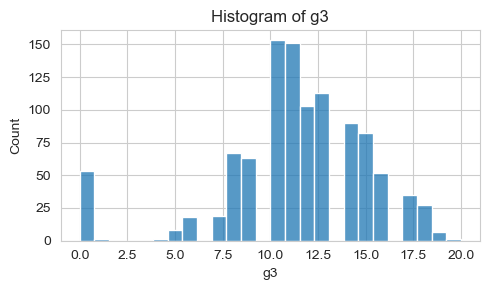

In [933]:
# Reusable histogram function
def plot_histogram(df, column):
    plt.figure(figsize=(5, 3))  # Compact, report-ready size
    sns.histplot(df[column].dropna(), kde=False)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(f"Histogram of {column}")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "g3"
plot_histogram(df_raw, plot_column)

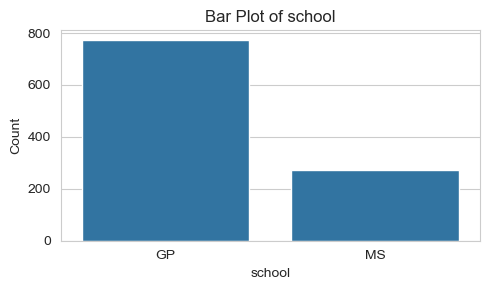

In [934]:
# Reusable bar plot function for categorical variables
def plot_bar(df, column):
    plt.figure(figsize=(5, 3))  # Compact, report-ready size
    sns.countplot(data=df, x=column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(f"Bar Plot of {column}")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "school"
plot_bar(df_raw, plot_column)

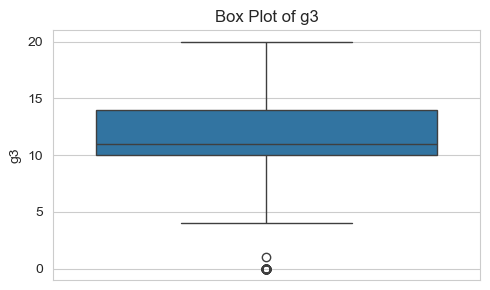

In [935]:
# Reusable box plot function for a numerical column
def plot_box(df, column):
    plt.figure(figsize=(5, 3))  # Compact, report-ready size
    sns.boxplot(y=df[column])
    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "g3"
plot_box(df_raw, plot_column)

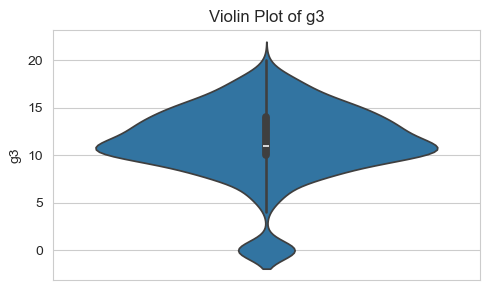

In [936]:
# Reusable violin plot function for a numerical column
def plot_violin(df, column):
    plt.figure(figsize=(5, 3))  # Compact, report-ready size
    sns.violinplot(y=df[column])
    plt.title(f"Violin Plot of {column}")
    plt.ylabel(column)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "g3"
plot_violin(df_raw, plot_column)

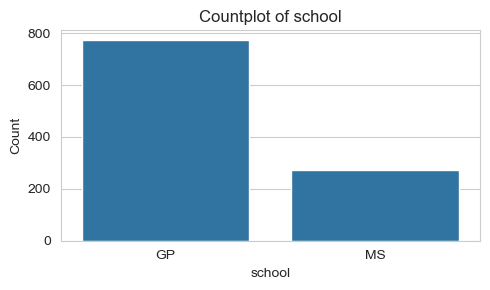

In [937]:
# Reusable countplot function for a categorical variable
def plot_countplot(df, column):
    plt.figure(figsize=(5, 3))
    sns.countplot(data=df, x=column)
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.title(f"Countplot of {column}")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "school"
plot_countplot(df_raw, plot_column)

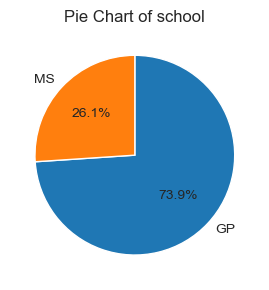

In [938]:
# Reusable pie chart function for a categorical variable
def plot_pie(df, column):
    plt.figure(figsize=(5, 3))
    df[column].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, counterclock=False)
    plt.ylabel("")
    plt.title(f"Pie Chart of {column}")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "school"
plot_pie(df_raw, plot_column)

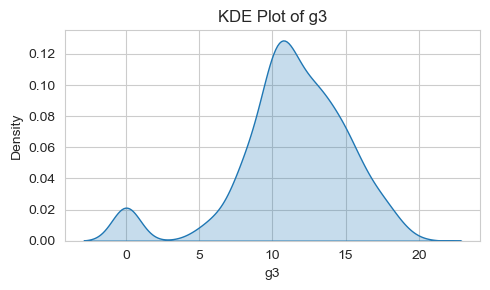

In [939]:
# Reusable KDE plot function for a numerical column
def plot_kde(df, column):
    plt.figure(figsize=(5, 3))
    sns.kdeplot(df[column].dropna(), fill=True)
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.title(f"KDE Plot of {column}")
    plt.tight_layout()
    plt.show()

# Example usage
plot_column = "g3"
plot_kde(df_raw, plot_column)

In [940]:
# Value counts table for a categorical variable
def show_value_counts(df, column):
    counts = df[column].value_counts(dropna=False)
    display(counts.to_frame(name="count"))

# Example usage
show_value_counts(df_raw, "school")

,count
school,
GP,772
MS,272


### 2.2 Bivariate Analysis

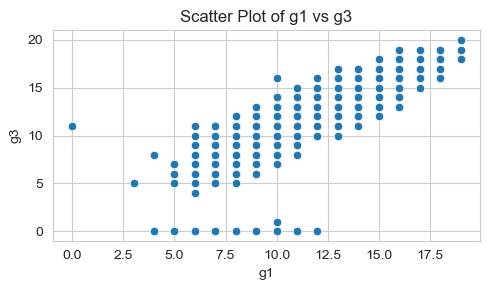

In [941]:
# Scatter plot: g1 vs g3
plt.figure(figsize=(5, 3))
sns.scatterplot(data=df_raw, x="g1", y="g3")
plt.xlabel("g1")
plt.ylabel("g3")
plt.title("Scatter Plot of g1 vs g3")
plt.tight_layout()
plt.show()

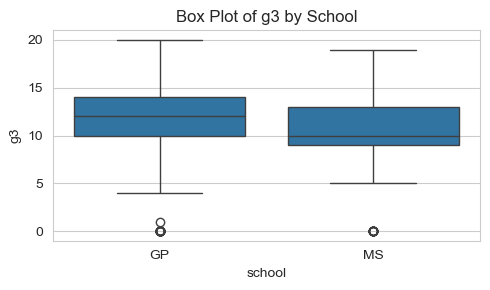

In [942]:
# Box plot: g3 by school
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_raw, x="school", y="g3")
plt.xlabel("school")
plt.ylabel("g3")
plt.title("Box Plot of g3 by School")
plt.tight_layout()
plt.show()

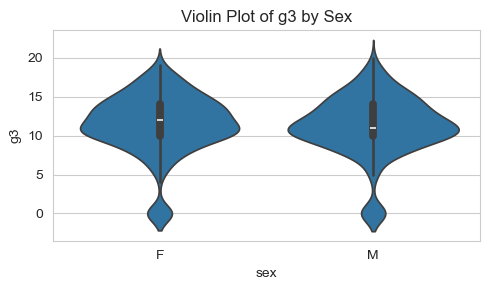

In [943]:
# Violin plot: g3 by sex
plt.figure(figsize=(5, 3))
sns.violinplot(data=df_raw, x="sex", y="g3")
plt.xlabel("sex")
plt.ylabel("g3")
plt.title("Violin Plot of g3 by Sex")
plt.tight_layout()
plt.show()

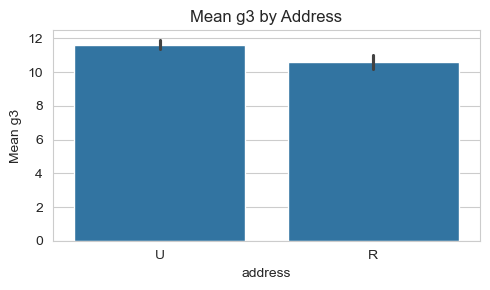

In [944]:
# Bar plot: mean g3 by address
plt.figure(figsize=(5, 3))
sns.barplot(data=df_raw, x="address", y="g3", estimator=np.mean)
plt.xlabel("address")
plt.ylabel("Mean g3")
plt.title("Mean g3 by Address")
plt.tight_layout()
plt.show()

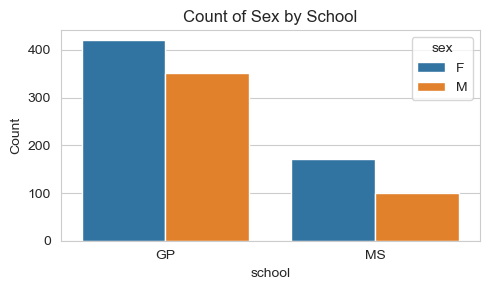

In [945]:
# Countplot: sex by school
plt.figure(figsize=(5, 3))
sns.countplot(data=df_raw, x="school", hue="sex")
plt.xlabel("school")
plt.ylabel("Count")
plt.title("Count of Sex by School")
plt.tight_layout()
plt.show()

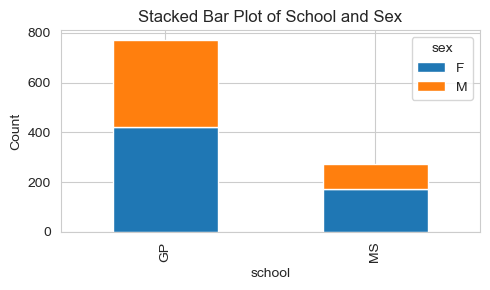

In [946]:
# Stacked bar plot: school vs sex
pd.crosstab(df_raw["school"], df_raw["sex"]).plot(kind="bar", stacked=True, figsize=(5, 3))
plt.xlabel("school")
plt.ylabel("Count")
plt.title("Stacked Bar Plot of School and Sex")
plt.tight_layout()
plt.show()

### 2.3 Correlation Analysis

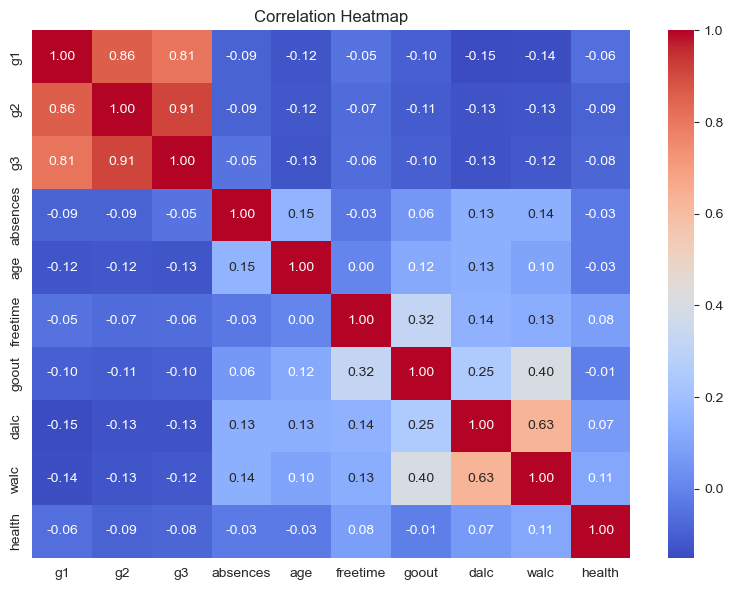

In [947]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(8, 6))
corr = df_raw[["g1", "g2", "g3", "absences", "age", "freetime", "goout", "dalc", "walc", "health"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Task 3: Data Modelling

### 3.1 Regression Task

#### 3.1.1 Data Preprocessing

In [948]:
df_prep_reg = df_raw.copy()
df_prep_clf = df_raw.copy()

##### 3.1.1.1 Handle Duplication

In [949]:
# Remove duplicate rows from the preprocessed dataset
df_prep_reg = df_prep_reg.drop_duplicates()
print(f"Shape after removing duplicates: {df_prep_reg.shape}")

Shape after removing duplicates: (1044, 33)


##### 3.1.1.2 Feature Engineering (Optional)

In [950]:
# # Example feature engineering: create a new feature 'average_grade' as the mean of g1, g2, g3
# df_prep_reg["average_grade"] = df_prep_reg[["g1", "g2", "g3"]].mean(axis=1)

# # Example: create a binary feature 'high_absence' if absences > 10
# df_prep_reg["high_absence"] = (df_prep_reg["absences"] > 10).astype(int)

##### 3.1.1.3 Split the Data

In [951]:
# Example: Predicting 'g3' as the target
X = df_prep_reg.drop("g3", axis=1)
y = df_prep_reg["g3"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=None
)

print(f"Train shape: {X_train_reg.shape}, Test shape: {X_test_reg.shape}")

Train shape: (835, 32), Test shape: (209, 32)


##### 3.1.1.4 Impute Missing Values

In [952]:
# Separate numeric and categorical columns
num_cols = X_train_reg.select_dtypes(include=[np.number]).columns
cat_cols = X_train_reg.select_dtypes(exclude=[np.number]).columns

# Numeric imputation options: "mean", "median", "most_frequent", "constant"
num_imputer = SimpleImputer(strategy="mean")  # Change to "median", "most_frequent", or "constant" as needed
X_train_reg[num_cols] = num_imputer.fit_transform(X_train_reg[num_cols])
X_test_reg[num_cols] = num_imputer.transform(X_test_reg[num_cols])

# Categorical imputation options: "most_frequent", "constant"
cat_imputer = SimpleImputer(strategy="most_frequent")  # Change to "constant" and fill_value="unknown" if needed
# Example for "constant":
# cat_imputer = SimpleImputer(strategy="constant", fill_value="unknown")
X_train_reg[cat_cols] = cat_imputer.fit_transform(X_train_reg[cat_cols])
X_test_reg[cat_cols] = cat_imputer.transform(X_test_reg[cat_cols])

# Check if any missing values remain
print("Missing values in X_train:", X_train_reg.isnull().sum().sum())
print("Missing values in X_test:", X_test_reg.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


##### 3.1.1.5 Encode categorical

In [953]:
# Choose encoding method: "ordinal" or "onehot"
encoding_method = "ordinal"  # Change to "onehot" if needed

if len(cat_cols) > 0:
    if encoding_method == "ordinal":
        # Ordinal encoding
        ord_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_train_reg[cat_cols] = ord_encoder.fit_transform(X_train_reg[cat_cols])
        X_test_reg[cat_cols] = ord_encoder.transform(X_test_reg[cat_cols])
    elif encoding_method == "onehot":
        # One-hot encoding (returns numpy arrays, so you may want to convert back to DataFrame)
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
        X_train_ohe = ohe.fit_transform(X_train_reg[cat_cols])
        X_test_ohe = ohe.transform(X_test_reg[cat_cols])
        # Create DataFrames with new column names
        ohe_cols = ohe.get_feature_names_out(cat_cols)
        X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train_reg.index)
        X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test_reg.index)
        # Drop original categorical columns and concat encoded columns
        X_train_reg = pd.concat([X_train_reg.drop(cat_cols, axis=1), X_train_ohe], axis=1)
        X_test_reg = pd.concat([X_test_reg.drop(cat_cols, axis=1), X_test_ohe], axis=1)

print("Categorical encoding complete. X_train shape:", X_train_reg.shape)

Categorical encoding complete. X_train shape: (835, 32)


##### 3.1.1.6 Scale features

In [954]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Choose scaling method: "standard" or "minmax"
scaling_method = "standard"  # Change to "minmax" if needed

# Identify numeric columns (after encoding, all should be numeric, but you can specify if needed)
num_cols = X_train_reg.select_dtypes(include=[np.number]).columns

if scaling_method == "standard":
    scaler = StandardScaler()
elif scaling_method == "minmax":
    scaler = MinMaxScaler()

X_train_reg[num_cols] = scaler.fit_transform(X_train_reg[num_cols])
X_test_reg[num_cols] = scaler.transform(X_test_reg[num_cols])

##### 3.1.1.7 Outlier removal

In [955]:
# # Remove outliers from training data using the IQR method

# def remove_outliers_iqr(X, y, factor=1.5):
#     X_no_out = X.copy()
#     y_no_out = y.copy()
#     num_cols = X_no_out.select_dtypes(include=[np.number]).columns
#     for col in num_cols:
#         Q1 = X_no_out[col].quantile(0.25)
#         Q3 = X_no_out[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower = Q1 - factor * IQR
#         upper = Q3 + factor * IQR
#         mask = (X_no_out[col] >= lower) & (X_no_out[col] <= upper)
#         X_no_out = X_no_out[mask]
#         y_no_out = y_no_out[mask]
#     return X_no_out, y_no_out

# X_train_reg, y_train_reg = remove_outliers_iqr(X_train_reg, y_train_reg)
# print("Shape after outlier removal:", X_train_reg.shape)

#### 3.1.2 Model Selection & Training

In [956]:
# --- Regression Models (noise-resilient, low parameter count) ---

from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Ridge Regression: stable under noise + correlated features (single key param: alpha)
reg_model_ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)

# 2. Huber Regressor: robust to outliers/noisy targets (few params: epsilon, alpha)
reg_model_huber = HuberRegressor(epsilon=1.35, alpha=1e-4, max_iter=1000)

# 3. Random Forest Regressor (constrained): robust to noise + nonlinearity (few explainable params)
reg_model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [957]:
# Train regression models
reg_model_ridge.fit(X_train_reg, y_train_reg)
reg_model_rf.fit(X_train_reg, y_train_reg)
reg_model_huber.fit(X_train_reg, y_train_reg)

print("All selected models have been trained.")

All selected models have been trained.


#### 3.1.3 Model Evaluation

In [958]:
# Predict on test set
y_pred_ridge = reg_model_ridge.predict(X_test_reg)
y_pred_rf    = reg_model_rf.predict(X_test_reg)
y_pred_huber = reg_model_huber.predict(X_test_reg)

# Metrics helper
def regression_metrics_row(y_true, y_pred, model_name):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    med  = median_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    evs  = explained_variance_score(y_true, y_pred)

    y_range = float(y_true.max() - y_true.min())
    nrmse = rmse / y_range if y_range != 0 else float("nan")

    return {
        "Model": model_name,
        "RMSE": rmse,
        "NRMSE": nrmse,
        "MAE": mae,
        "MedAE": med,
        "R2": r2,
        "ExplainedVar": evs,
    }

# Build results table
rows = [
    regression_metrics_row(y_test_reg, y_pred_ridge, "Ridge"),
    regression_metrics_row(y_test_reg, y_pred_rf, "Random Forest"),
    regression_metrics_row(y_test_reg, y_pred_huber, "Huber"),
]

df_metrics = pd.DataFrame(rows).set_index("Model")
df_metrics = df_metrics.round(3)

display(df_metrics)


,RMSE,NRMSE,MAE,MedAE,R2,ExplainedVar
Model,,,,,,
Ridge,1.776,0.093,1.038,0.678,0.796,0.796
Random Forest,1.664,0.088,0.915,0.523,0.821,0.822
Huber,1.765,0.093,0.939,0.578,0.798,0.802


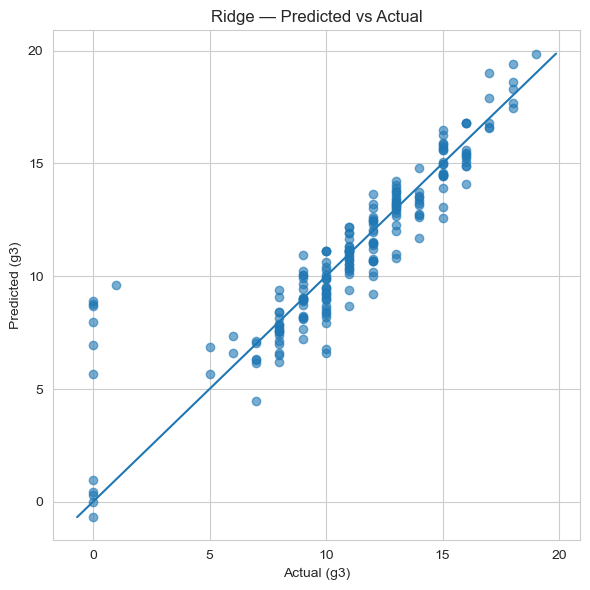

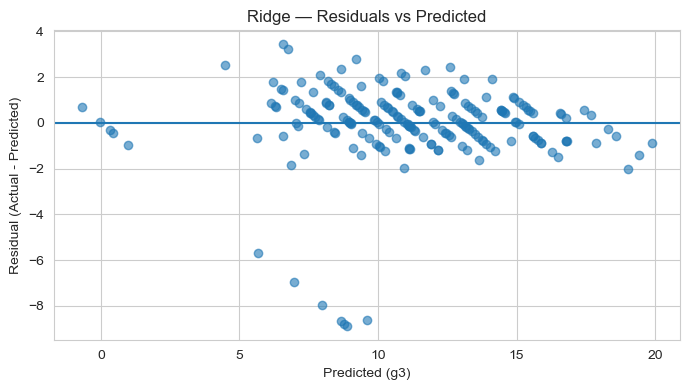

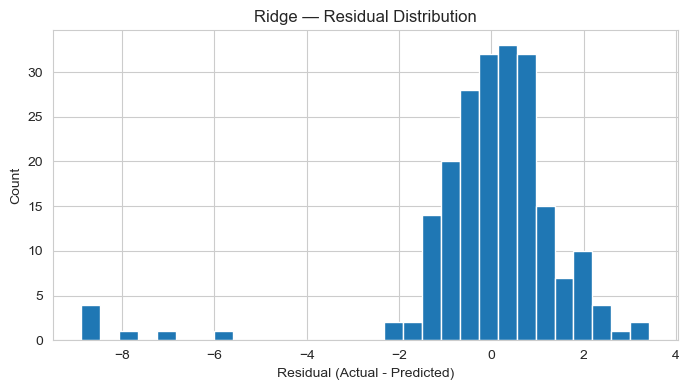

/var/folders/g7/55bmzk2j5mb3_5wz5p1dd2qm0000gn/T/ipykernel_11599/2904667686.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


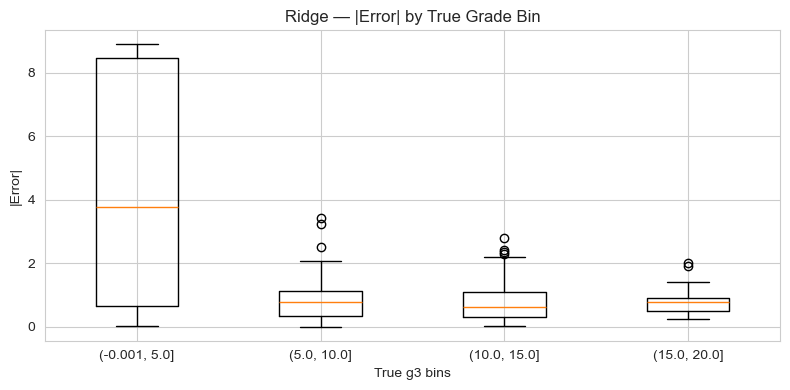

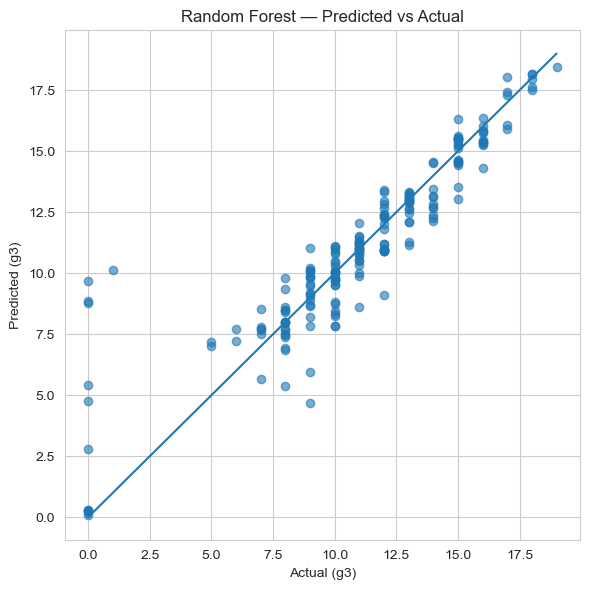

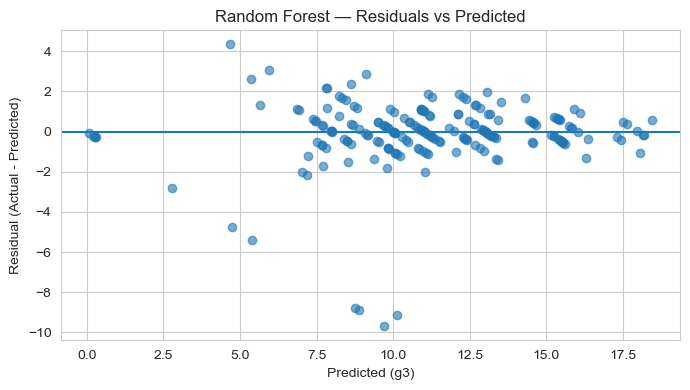

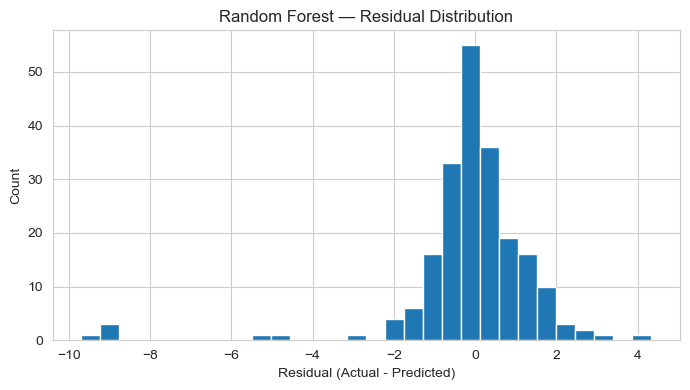

/var/folders/g7/55bmzk2j5mb3_5wz5p1dd2qm0000gn/T/ipykernel_11599/2904667686.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


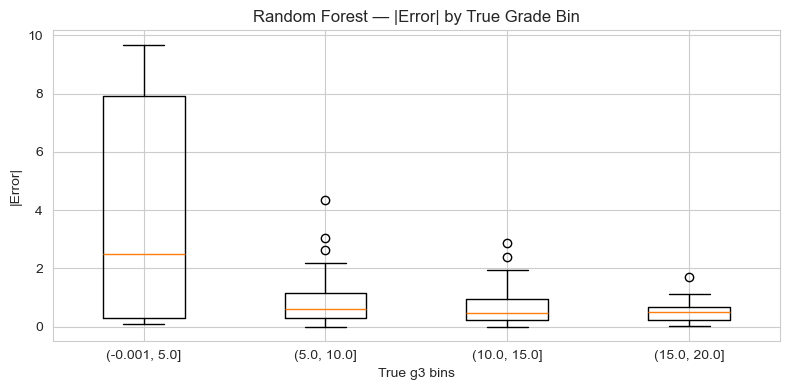

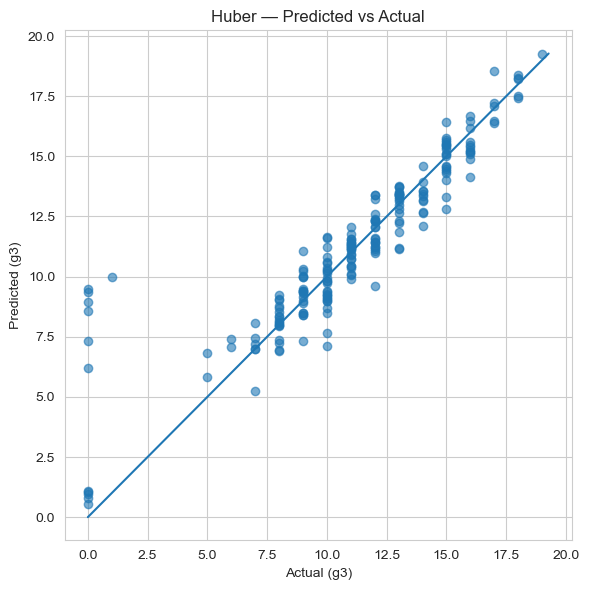

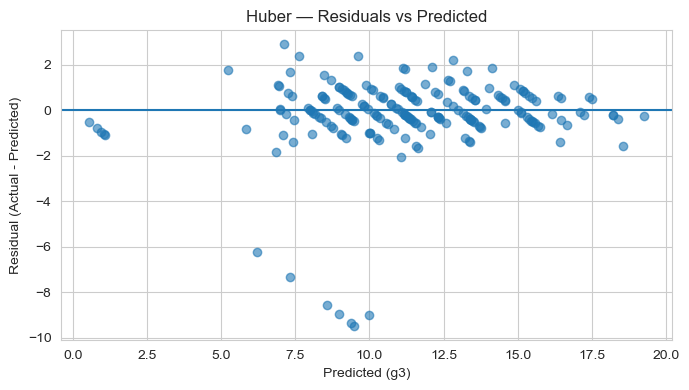

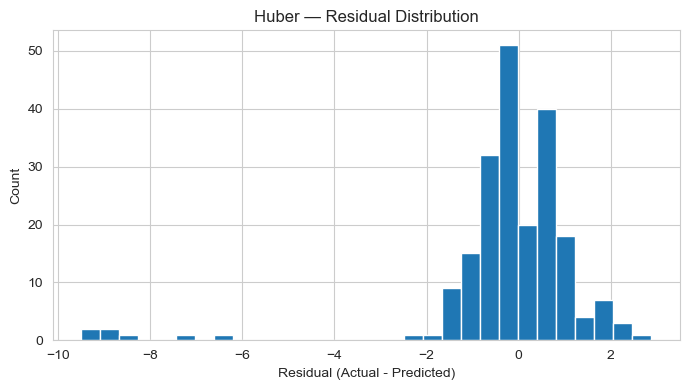

/var/folders/g7/55bmzk2j5mb3_5wz5p1dd2qm0000gn/T/ipykernel_11599/2904667686.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


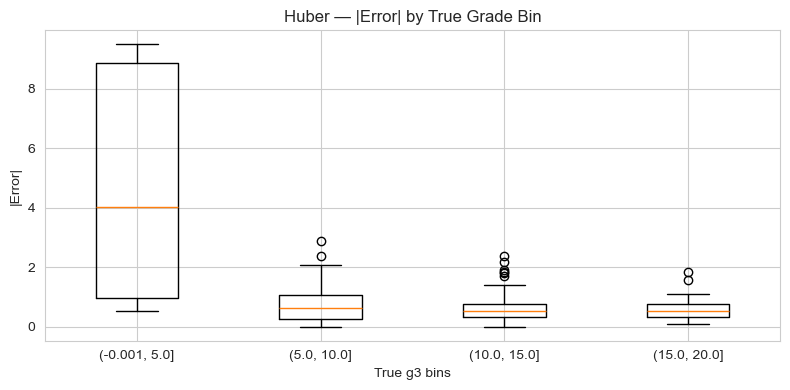

In [959]:
preds = {
    "Ridge": y_pred_ridge,
    "Random Forest": y_pred_rf,
    "Huber": y_pred_huber,
}

y_true = np.asarray(y_test_reg)

def plot_pred_vs_actual(y_true, y_pred, title):
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)

    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    plt.plot([lo, hi], [lo, hi])  # y = x reference

    plt.xlabel("Actual (g3)")
    plt.ylabel("Predicted (g3)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residuals_vs_pred(y_true, y_pred, title):
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0)

    plt.xlabel("Predicted (g3)")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_residual_hist(y_true, y_pred, title, bins=30):
    y_pred = np.asarray(y_pred)
    residuals = y_true - y_pred

    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=bins)

    plt.xlabel("Residual (Actual - Predicted)")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_abs_error_by_true_bins(y_true, y_pred, title, bin_edges=None):
    y_pred = np.asarray(y_pred)
    abs_err = np.abs(y_true - y_pred)

    if bin_edges is None:
        bin_edges = [0, 5, 10, 15, 20]

    cats = pd.cut(y_true, bins=bin_edges, include_lowest=True, right=True)
    df_plot = pd.DataFrame({"bin": cats, "abs_err": abs_err})

    groups = [g["abs_err"].values for _, g in df_plot.groupby("bin", observed=True)]
    labels = [str(k) for k, _ in df_plot.groupby("bin", observed=True)]

    plt.figure(figsize=(8, 4))
    plt.boxplot(groups, labels=labels, showfliers=True)
    plt.xlabel("True g3 bins")
    plt.ylabel("|Error|")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---- Generate plots ----
for name, y_pred in preds.items():
    plot_pred_vs_actual(y_true, y_pred, f"{name} — Predicted vs Actual")
    plot_residuals_vs_pred(y_true, y_pred, f"{name} — Residuals vs Predicted")
    plot_residual_hist(y_true, y_pred, f"{name} — Residual Distribution")
    plot_abs_error_by_true_bins(y_true, y_pred, f"{name} — |Error| by True Grade Bin")


### 3.2 Classification Task

#### 3.2.1 Data Preprocessing

#### 3.2.1.1 Handle Duplication

In [960]:
# Remove duplicate rows from the preprocessed dataset
df_prep_clf = df_prep_clf.drop_duplicates()
print(f"Shape after removing duplicates: {df_prep_clf.shape}")

Shape after removing duplicates: (1044, 33)


##### 3.2.1.2 Feature Engineering  (Optional)

In [961]:
df_prep_clf = df_prep_clf.copy()

bins = [-1, 9, 13, 16, 20]  # right-inclusive by default
labels = ["Fail", "Pass", "Good", "Excellent"]

df_prep_clf["g3_level"] = pd.cut(
    df_prep_clf["g3"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Optional: numeric encoding for models that expect integers
level_map = {"Fail": 0, "Pass": 1, "Good": 2, "Excellent": 3}
df_prep_clf["g3_level_code"] = df_prep_clf["g3_level"].map(level_map).astype("int64")

print(df_prep_clf["g3_level"].value_counts().sort_index())

g3_level
Fail         230
Pass         520
Good         224
Excellent     70
Name: count, dtype: int64


##### 3.2.1.3 Split the Data

In [962]:
# Example: Predicting 'g3' as the target
df_prep_clf = df_prep_clf.drop("g3", axis=1)
df_prep_clf = df_prep_clf.drop("g1", axis=1)
df_prep_clf = df_prep_clf.drop("g2", axis=1)
X = df_prep_clf.drop("g3_level", axis=1)
y = df_prep_clf["g3_level"]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=None
)

print(f"Train shape: {X_train_clf.shape}, Test shape: {X_test_clf.shape}")

X_train_clf.head()

Train shape: (835, 31), Test shape: (209, 31)


,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,dalc,walc,health,absences,g3_level_code
531,GP,M,16,U,GT3,T,2,1,at_home,other,course,mother,4,1,0,no,no,no,no,yes,yes,no,no,3,2,1,1,1,2,4,1
256,GP,F,17,U,LE3,T,4,2,teacher,services,reputation,mother,1,4,0,no,yes,yes,yes,yes,yes,yes,no,4,2,3,1,1,4,6,1
350,MS,M,19,R,GT3,T,1,1,other,services,home,other,3,2,3,no,no,no,no,yes,yes,yes,no,5,4,4,3,3,2,8,0
60,GP,F,16,R,GT3,T,4,4,health,teacher,other,mother,1,2,0,no,yes,no,yes,yes,yes,no,no,2,4,4,2,3,4,6,1
930,MS,M,15,R,GT3,T,1,2,other,services,course,mother,3,2,0,no,yes,no,yes,yes,yes,no,no,5,5,5,1,3,5,11,1


##### 3.2.1.4 Impute Missing Values

In [963]:
# Separate numeric and categorical columns
num_cols = X_train_clf.select_dtypes(include=[np.number]).columns
cat_cols = X_train_clf.select_dtypes(exclude=[np.number]).columns

# Numeric imputation options: "mean", "median", "most_frequent", "constant"
num_imputer = SimpleImputer(strategy="mean")  # Change to "median", "most_frequent", or "constant" as needed
X_train_clf[num_cols] = num_imputer.fit_transform(X_train_clf[num_cols])
X_test_clf[num_cols] = num_imputer.transform(X_test_clf[num_cols])

# Categorical imputation options: "most_frequent", "constant"
cat_imputer = SimpleImputer(strategy="most_frequent")  # Change to "constant" and fill_value="unknown" if needed
# Example for "constant":
# cat_imputer = SimpleImputer(strategy="constant", fill_value="unknown")
X_train_clf[cat_cols] = cat_imputer.fit_transform(X_train_clf[cat_cols])
X_test_clf[cat_cols] = cat_imputer.transform(X_test_clf[cat_cols])

# Check if any missing values remain
print("Missing values in X_train:", X_train_clf.isnull().sum().sum())
print("Missing values in X_test:", X_test_clf.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


##### 3.2.1.5 Encode Categorical

In [964]:
# Choose encoding method: "ordinal" or "onehot"
encoding_method = "ordinal"  # Change to "onehot" if needed

if len(cat_cols) > 0:
    if encoding_method == "ordinal":
        # Ordinal encoding
        ord_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        X_train_clf[cat_cols] = ord_encoder.fit_transform(X_train_clf[cat_cols])
        X_test_clf[cat_cols] = ord_encoder.transform(X_test_clf[cat_cols])
    elif encoding_method == "onehot":
        # One-hot encoding (returns numpy arrays, so you may want to convert back to DataFrame)
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
        X_train_ohe = ohe.fit_transform(X_train_clf[cat_cols])
        X_test_ohe = ohe.transform(X_test_clf[cat_cols])
        # Create DataFrames with new column names
        ohe_cols = ohe.get_feature_names_out(cat_cols)
        X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train_clf.index)
        X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test_clf.index)
        # Drop original categorical columns and concat encoded columns
        X_train_clf = pd.concat([X_train_clf.drop(cat_cols, axis=1), X_train_ohe], axis=1)
        X_test_clf = pd.concat([X_test_clf.drop(cat_cols, axis=1), X_test_ohe], axis=1)

print("Categorical encoding complete. X_train shape:", X_train_clf.shape)

Categorical encoding complete. X_train shape: (835, 31)


##### 3.2.1.6 Outlier Removal

In [965]:
# # Remove outliers from training data using the IQR method

# def remove_outliers_iqr(X, y, factor=1.5):
#     X_no_out = X.copy()
#     y_no_out = y.copy()
#     num_cols = X_no_out.select_dtypes(include=[np.number]).columns
#     for col in num_cols:
#         Q1 = X_no_out[col].quantile(0.25)
#         Q3 = X_no_out[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower = Q1 - factor * IQR
#         upper = Q3 + factor * IQR
#         mask = (X_no_out[col] >= lower) & (X_no_out[col] <= upper)
#         X_no_out = X_no_out[mask]
#         y_no_out = y_no_out[mask]
#     return X_no_out, y_no_out

# X_train_clf, y_train_clf = remove_outliers_iqr(X_train_clf, y_train_clf)
# print("Shape after outlier removal:", X_train_clf.shape)

#### 3.2.2 Model Selection & Training

In [966]:
# --- Classification Models (noise-tolerant, few parameters, easy to justify) ---

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1) Logistic Regression (regularised)
clf_model_lr = LogisticRegression(
    C=1.0,                 # smaller C => stronger regularisation
    penalty="l2",
    solver="liblinear",    # reliable for small/medium tabular datasets
    class_weight="balanced",  # helps if classes are imbalanced
    random_state=RANDOM_STATE,
    max_iter=2000
)

# 2) Decision Tree (constrained)
clf_model_dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

# 3) Random Forest (constrained)
clf_model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

classification_models = {
    "Logistic Regression": clf_model_lr,
    "Decision Tree": clf_model_dt,
    "Random Forest": clf_model_rf,
}

print("Classification models initialised:", list(classification_models.keys()))

Classification models initialised: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [967]:
# Train regression models
clf_model_lr.fit(X_train_clf, y_train_clf)
clf_model_dt.fit(X_train_clf, y_train_clf)
clf_model_rf.fit(X_train_clf, y_train_clf)

print("All selected models have been trained.")

/Users/pnm/miniconda3/envs/pds-a1/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


All selected models have been trained.


#### 3.2.3 Model Evaluation

In [968]:

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Assumes:
# - classification_models: dict of fitted models
# - X_test_cls, y_test_cls (now multiclass integers 0..K-1)

def classification_metrics_row_multiclass(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "Precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

rows = []
for name, model in classification_models.items():
    y_pred = model.predict(X_test_clf)
    rows.append(classification_metrics_row_multiclass(y_test_clf, y_pred, name))

df_cls_metrics = pd.DataFrame(rows).set_index("Model").round(3)
display(df_cls_metrics)

# Confusion matrix (per model)
labels = sorted(np.unique(y_test_clf))
for name, model in classification_models.items():
    y_pred = model.predict(X_test_clf)
    cm = confusion_matrix(y_test_clf, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"True_{c}" for c in labels], columns=[f"Pred_{c}" for c in labels])
    print(f"\n{name} — Confusion Matrix")
    display(cm_df)

,Accuracy,BalancedAcc,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted
Model,,,,,,,,
Logistic Regression,0.952,0.938,0.959,0.938,0.948,0.952,0.952,0.952
Decision Tree,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
Random Forest,0.990,0.971,0.992,0.971,0.981,0.990,0.990,0.990



Logistic Regression — Confusion Matrix


,Pred_Excellent,Pred_Fail,Pred_Good,Pred_Pass
True_Excellent,10,0,1,0
True_Fail,0,60,0,0
True_Good,0,0,38,5
True_Pass,0,1,3,91



Decision Tree — Confusion Matrix


,Pred_Excellent,Pred_Fail,Pred_Good,Pred_Pass
True_Excellent,11,0,0,0
True_Fail,0,60,0,0
True_Good,0,0,43,0
True_Pass,0,0,0,95



Random Forest — Confusion Matrix


,Pred_Excellent,Pred_Fail,Pred_Good,Pred_Pass
True_Excellent,10,0,1,0
True_Fail,0,60,0,0
True_Good,0,0,42,1
True_Pass,0,0,0,95
